# Decent Results from Dimensionality Reduction
### Dimensionality Reduction Algorithms in Scikit-Learn

Dimensionality Reduction sounds like (and is!) a very powerful tool for analysis of features. So, let's walk through the different algorithms available to us, and see how we can use it to our advantage.

In [1]:
import sklearn
import matplotlib.pyplot as plt
import numpy as np

We had some issue with the diabetes dataset earlier, so let's use Dimensionality Reduction to see if we can find any trends. 

In [3]:
X, y = sklearn.datasets.load_diabetes(return_X_y=True)

### PCA
PCA is the most standard way to perform dimensionality reduction. Let's see it in action.

In [6]:
pca = sklearn.decomposition.PCA(n_components=2)
X_reduced = pca.fit_transform(X, y)

We can see the weightage of the components when using PCA! We can also see how much each dimension contributes to explaining the variance.

In [10]:
pca.components_

array([[ 0.2164309 ,  0.18696688,  0.30316216,  0.27173773,  0.34325511,
         0.35186068, -0.28243681,  0.4288337 ,  0.37861802,  0.32218296],
       [ 0.04436721, -0.3865472 , -0.15628128, -0.138266  ,  0.57302691,
         0.45594185,  0.50623907, -0.06818072, -0.026187  , -0.08494884]])

In [9]:
pca.explained_variance_ratio_

array([0.40242108, 0.14923197])

Let's plot the output...

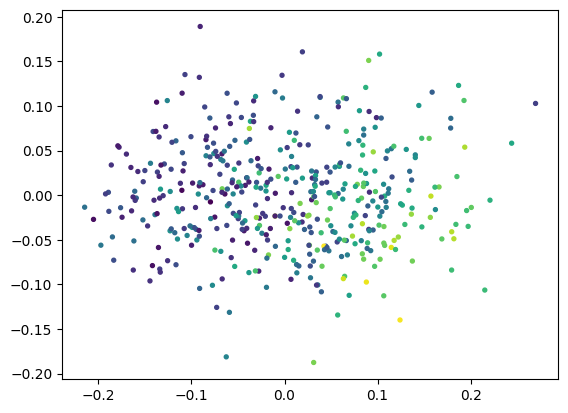

In [11]:
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], s=8, c=y)

Alright, not a very clean split... but still a trend regardless.  

With PCA, we can also investigate how many compopnents we want to decompose to.

In [34]:
pca = sklearn.decomposition.PCA() # by default, will keep all features
X_reduced = pca.fit_transform(X, y)
pca.explained_variance_ratio_

array([0.40242108, 0.14923197, 0.12059663, 0.09554764, 0.06621814,
       0.06027171, 0.05365657, 0.0433682 , 0.007832  , 0.00085607])

If the first three dimensions explain the variance about 75% of the time, we can plot it out in 3D space! However, when doing analysis it is possible for us to just throw the last few columns which have weak significane.

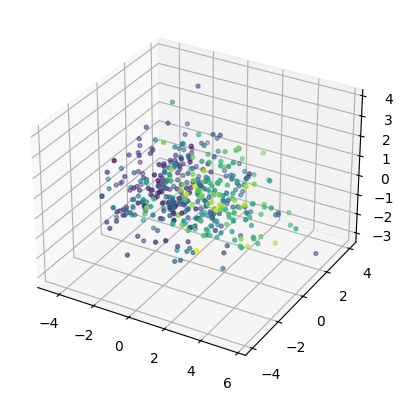

In [37]:
ax = plt.figure().add_subplot(projection="3d")
ax.scatter(X_reduced[:, 0], X_reduced[:, 1], X_reduced[:, 2], s=8, c=y)

Looks somewhat more coherent...?

### t-SNE
t-SNE is straight up voodoo magic. However, read https://distill.pub/2016/misread-tsne/ for common pitfalls.  

t-SNE also requires some hyperparameter tuning. Let's work that out!

In [18]:
scaler = sklearn.preprocessing.StandardScaler()
X = scaler.fit_transform(X)

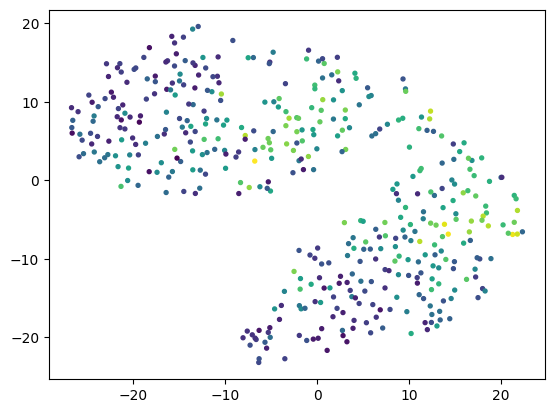

In [42]:
tsne = sklearn.manifold.TSNE()
X_reduced = tsne.fit_transform(X)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], s=8, c=y)

One issue is that t-SNE takes some time to run. In our case, it takes a few seconds to run on such a small dataset.  

However, results are not very appealing. We can try again!

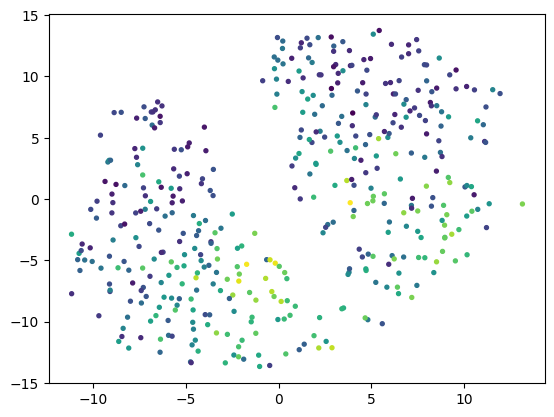

In [28]:
tsne = sklearn.manifold.TSNE(perplexity=50)
X_reduced = tsne.fit_transform(X)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], s=8, c=y)

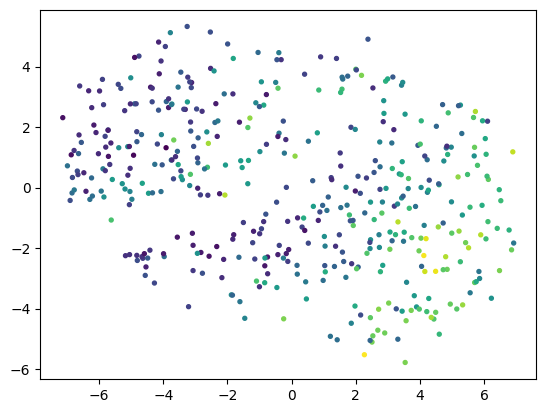

In [27]:
tsne = sklearn.manifold.TSNE(perplexity=100)
X_reduced = tsne.fit_transform(X)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], s=8, c=y)

There is still some pattern, but not too clear. Let's do a 3D projection to see if that helps.

In [31]:
tsne = sklearn.manifold.TSNE(n_components=3, perplexity=100)
X_reduced = tsne.fit_transform(X)

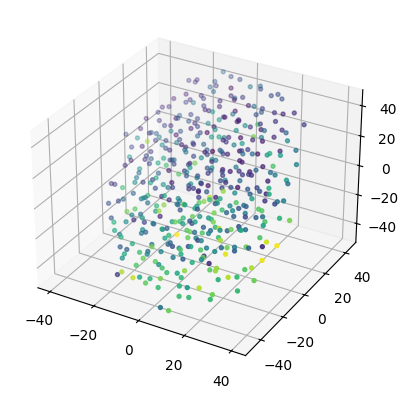

In [33]:
ax = plt.figure().add_subplot(projection="3d")
ax.scatter(X_reduced[:, 0], X_reduced[:, 1], X_reduced[:, 1], s=8, c=y)

A lot cleaner than the PCA one!

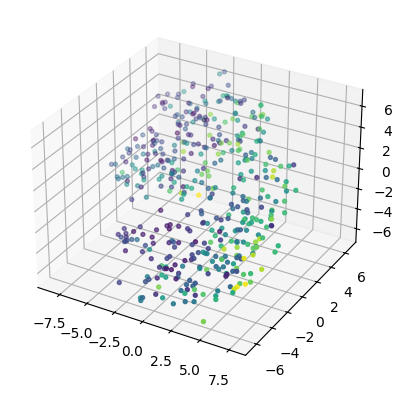

In [39]:
tsne = sklearn.manifold.TSNE(n_components=3, perplexity=50)
X_reduced = tsne.fit_transform(X)
ax = plt.figure().add_subplot(projection="3d")
ax.scatter(X_reduced[:, 0], X_reduced[:, 1], X_reduced[:, 1], s=8, c=y)

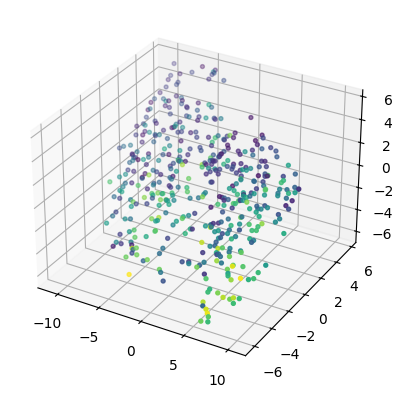

In [40]:
tsne = sklearn.manifold.TSNE(n_components=3)
X_reduced = tsne.fit_transform(X)
ax = plt.figure().add_subplot(projection="3d")
ax.scatter(X_reduced[:, 0], X_reduced[:, 1], X_reduced[:, 1], s=8, c=y)

### MAP (Manifold Approximation and Projection) and Friends 
MAP is a whole family of dimensionality reduction techniques, in fact, t-SNE is considered a form of MAP! But let's just run through each of the given functions and evaluate their performance.

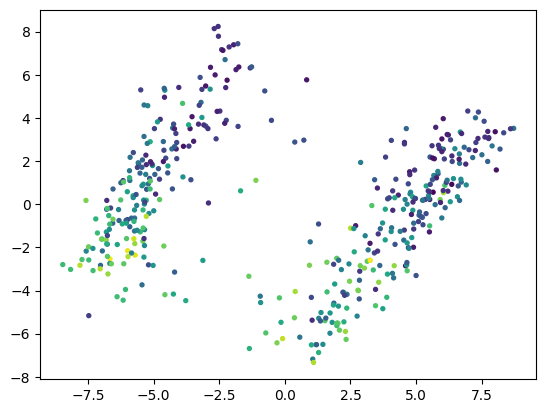

In [43]:
alg = sklearn.manifold.Isomap()
X_reduced = alg.fit_transform(X)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], s=8, c=y)

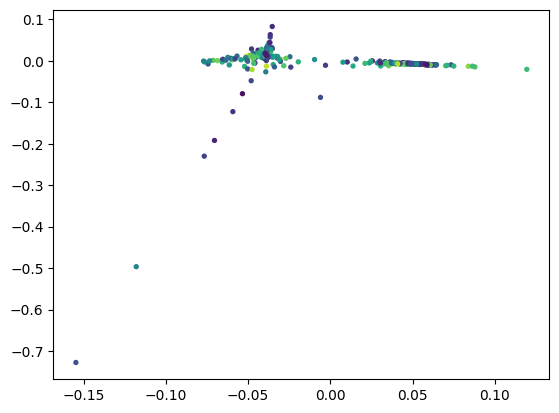

In [44]:
alg = sklearn.manifold.LocallyLinearEmbedding()
X_reduced = alg.fit_transform(X)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], s=8, c=y)

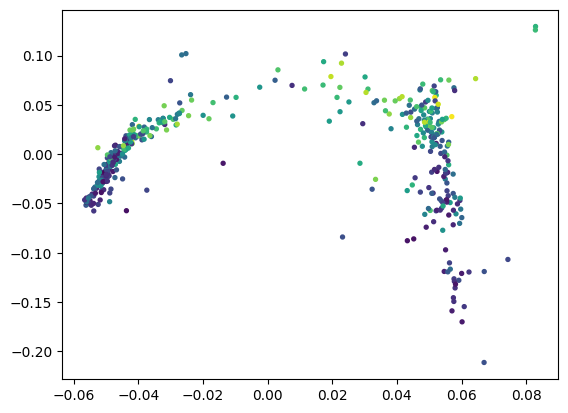

In [45]:
alg = sklearn.manifold.LocallyLinearEmbedding(method="modified")
X_reduced = alg.fit_transform(X)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], s=8, c=y)

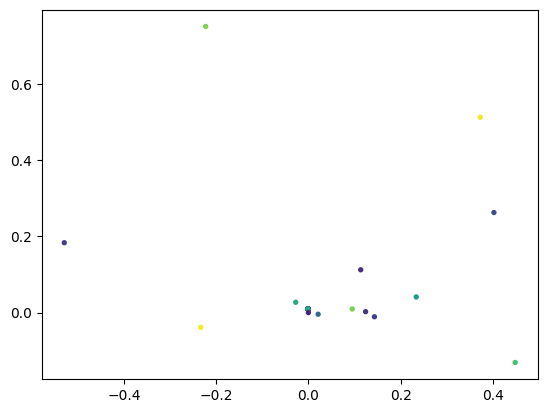

In [56]:
alg = sklearn.manifold.LocallyLinearEmbedding(method="hessian", n_neighbors=7, eigen_solver='dense')
X_reduced = alg.fit_transform(X)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], s=8, c=y)

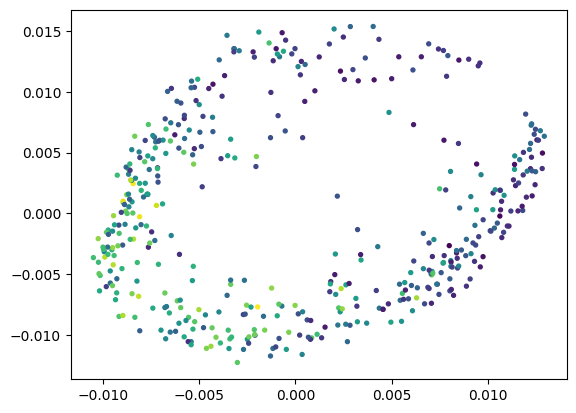

In [49]:
alg = sklearn.manifold.SpectralEmbedding()
X_reduced = alg.fit_transform(X)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], s=8, c=y)

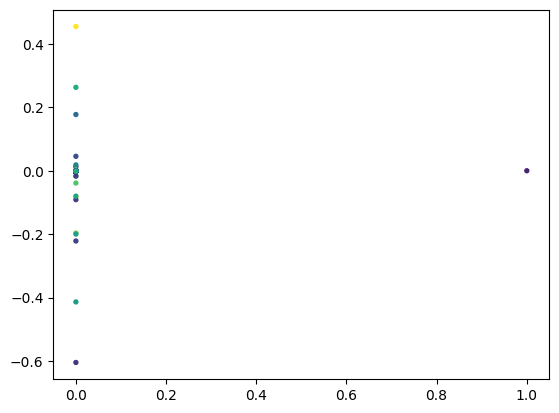

In [51]:
alg = sklearn.manifold.LocallyLinearEmbedding(method="ltsa", eigen_solver='dense')
X_reduced = alg.fit_transform(X)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], s=8, c=y)

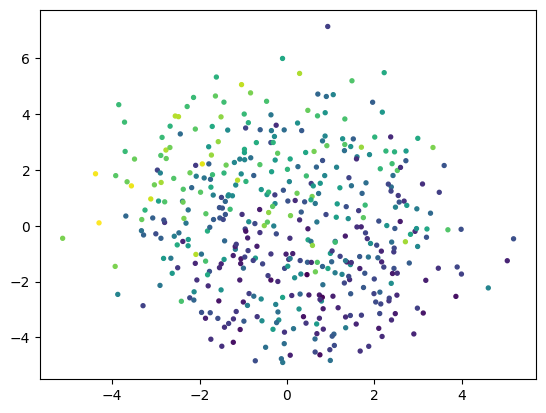

In [57]:
alg = sklearn.manifold.MDS()
X_reduced = alg.fit_transform(X)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], s=8, c=y)